# Historical Archival Document: Zero-Shot Style Transfer

## Motivation

The cross-lingual experiment showed that the Ukrainian style encoder captures language-agnostic
handwriting characteristics, enabling zero-shot generation from unseen English (IAM) writers.
This notebook pushes that claim further along **two additional axes simultaneously**:

1. **Unknown writer** — not in the 323 Ukrainian training writers
2. **Century-old handwriting** — pre-reform Ukrainian cursive from a ~1930s monastery
   Easter letter, sourced from the Ukrainian state archive (archium.tsdial.gov.ua)
3. **Different medium** — dip pen on aged paper vs. modern ballpoint/felt-tip in IAM and
   the Ukrainian training corpus

**Document:** Easter greeting *"Христос Воскрес!"* from the Studite Ukrainian monastery
(Монастир Студ. Укр., з Фіборинки). The writer is unknown and certainly absent from the
training set.

**Pipeline (identical to IAM experiment):**
1. Segment the page into individual word crops (CC-based segmenter, no TrOCR needed)
2. Select 5 representative words as style reference
3. Feed through `generate_word()` with `y=None` — pure continuous style conditioning,
   no writer index, no nearest-neighbour lookup

## Setup

In [1]:
import os, sys, cv2, random
import numpy as np
import torch
import torchvision
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
from scipy.ndimage import gaussian_filter1d
from IPython.display import display

sys.path.insert(0, '/home/oles/DiffusionPen')
from feature_extractor import ImageEncoder
from utils.word_dataset import char_classes as WORD_CHAR_CLASSES

DEVICE     = torch.device('cuda:0')
IMG_HEIGHT = 64
IMG_WIDTH  = 256

TRANSFORM = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

CHECKPOINT  = '/home/oles/DiffusionPen/output/diffusionpen_ukr_v9/models/ckpt.pt'
STYLE_PATH  = '/home/oles/DiffusionPen/style_models/ukr_mixed_wt0p7/mixed_ukr_mobilenetv2_100.pth'
SD_PATH     = '/home/oles/DiffusionPen/stable-diffusion-v1-5'
ARCHIVE_IMG = '/home/oles/DiffusionPen/723983.jpg'
OUTPUT_DIR  = '/home/oles/DiffusionPen/generated/archival'
CROPS_DIR   = os.path.join(OUTPUT_DIR, 'crops')
os.makedirs(CROPS_DIR, exist_ok=True)

print('Setup complete.')

/home/oles/DiffusionPen/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


num_tokens 1
Setup complete.


## Load Style Encoder

MobileNetV2 fine-tuned with triplet loss on Ukrainian handwriting.
Outputs a 1280-dim style vector per image; 5 reference images are mean-pooled.

In [2]:
style_extractor = ImageEncoder(model_name='mobilenetv2_100', num_classes=0,
                               pretrained=False, trainable=False)
style_sd   = torch.load(STYLE_PATH, map_location='cpu')
model_dict = style_extractor.state_dict()
style_sd   = {k: v for k, v in style_sd.items()
              if k in model_dict and model_dict[k].shape == v.shape}
model_dict.update(style_sd)
style_extractor.load_state_dict(model_dict)
style_extractor = style_extractor.to(DEVICE).eval()
print('Style encoder loaded. Output dim: 1280')

Style encoder loaded. Output dim: 1280


## Step 1: Segment the Archival Page into Word Crops

**Approach:**
1. Binarize the page with Otsu thresholding
2. Horizontal row projection → locate text line bands (rows > 5% of peak ink density)
3. For each line strip: CC-based word gap detection — merge components within 8 px,
   treat gaps ≥ 15 px as word boundaries. Same algorithm as the production segmenter.

Adjust `SIGMA`, `INK_THRESH`, `MERGE_DIST`, `MIN_GAP` if lines or words are over/under-split.

Original: 2000x2611  →  Working: 600x783 (scale=0.300)
Otsu threshold: 153  |  ink coverage: 4.0%
Detected 12 text line regions


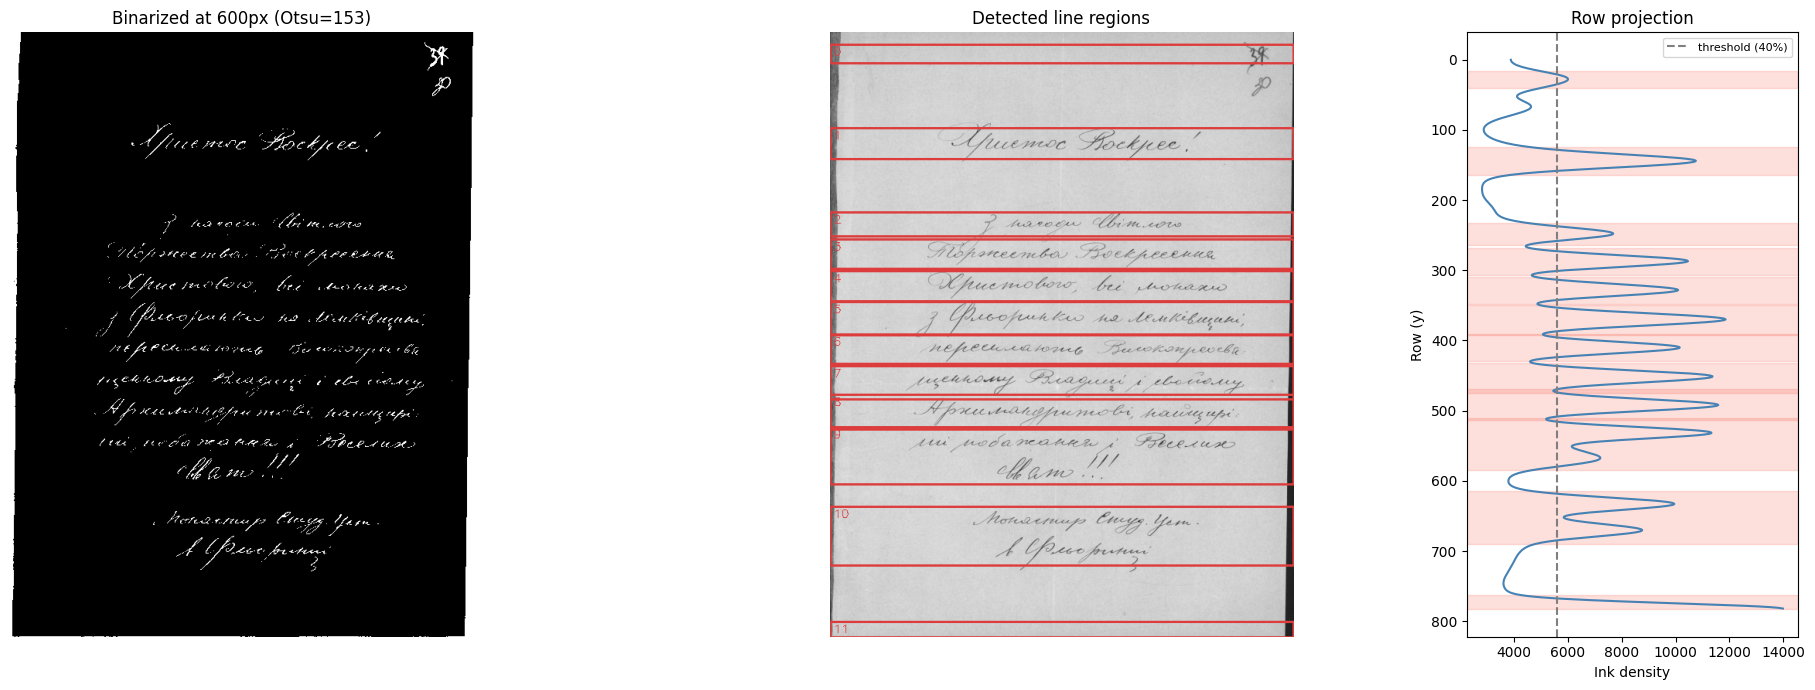

In [3]:
# ── tuneable parameters ───────────────────────────────────────────────────────
PROC_W     = 600   # scale image to this width before binarization
SIGMA      = 8     # row-projection smoothing (at 600px scale)
INK_THRESH = 0.40  # fraction of peak ink; rows BELOW → inter-line gap
#                    (must be high because aged-paper noise raises the floor)
LINE_PAD   = 5     # px above/below each detected line band
MERGE_DIST = 8     # px: CC components closer than this → same word
MIN_GAP    = 10    # px: gaps >= this → word boundary
MIN_WORD_W = 12    # px: crops narrower than this → discarded
# ─────────────────────────────────────────────────────────────────────────────

img_pil  = Image.open(ARCHIVE_IMG).convert('RGB')
img_gray = np.array(img_pil.convert('L'))
H_orig, W_orig = img_gray.shape

# Scale down — original 2000px has paper grain that breaks global thresholding
scale_f  = PROC_W / W_orig
proc_h   = int(H_orig * scale_f)
img_proc = cv2.resize(img_gray, (PROC_W, proc_h), interpolation=cv2.INTER_AREA)
H, W = img_proc.shape
print(f'Original: {W_orig}x{H_orig}  →  Working: {W}x{H} (scale={scale_f:.3f})')

# Otsu binarization at 600px scale
thresh_val, binary = cv2.threshold(
    img_proc, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
ink_pct = binary.sum() // 255 / (H * W) * 100
print(f'Otsu threshold: {thresh_val:.0f}  |  ink coverage: {ink_pct:.1f}%')

# Row projection — note: aged paper raises the floor, so INK_THRESH=0.40 not 0.05
row_proj = binary.sum(axis=1).astype(float)
smooth   = gaussian_filter1d(row_proj, sigma=SIGMA)
in_text  = (smooth > smooth.max() * INK_THRESH).astype(int)
diffs    = np.diff(np.concatenate([[0], in_text, [0]]))
starts   = np.where(diffs ==  1)[0]
ends     = np.where(diffs == -1)[0]
lines    = [(max(0, s - LINE_PAD), min(H, e + LINE_PAD))
            for s, e in zip(starts, ends)]
print(f'Detected {len(lines)} text line regions')

# Visualise
fig, axes = plt.subplots(1, 3, figsize=(20, 7),
                         gridspec_kw={'width_ratios': [2.5, 2.5, 1]})
axes[0].imshow(binary, cmap='gray')
axes[0].set_title(f'Binarized at {W}px (Otsu={thresh_val:.0f})'); axes[0].axis('off')

vis = cv2.cvtColor(img_proc, cv2.COLOR_GRAY2RGB)
for i, (y0, y1) in enumerate(lines):
    cv2.rectangle(vis, (0, y0), (W - 1, y1), (220, 60, 60), 2)
    cv2.putText(vis, str(i), (4, y0 + 14),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (220, 60, 60), 1)
axes[1].imshow(vis); axes[1].set_title('Detected line regions'); axes[1].axis('off')

axes[2].plot(smooth, np.arange(len(smooth)), color='steelblue', lw=1.5)
for y0, y1 in lines:
    axes[2].axhspan(y0, y1, alpha=0.25, color='salmon')
axes[2].axvline(smooth.max() * INK_THRESH, color='gray',
                ls='--', label=f'threshold ({INK_THRESH:.0%})')
axes[2].invert_yaxis()
axes[2].set_xlabel('Ink density'); axes[2].set_ylabel('Row (y)')
axes[2].set_title('Row projection'); axes[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

In [4]:
def segment_words(line_gray, merge_dist=MERGE_DIST, min_gap=MIN_GAP,
                  min_w=MIN_WORD_W, pad=2):
    """CC-based word segmentation on a downscaled line strip (Otsu)."""
    _, bw = cv2.threshold(line_gray, 0, 255,
                          cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    n, _, stats, _ = cv2.connectedComponentsWithStats(bw, connectivity=8)
    comps = sorted(
        [{'x':  int(stats[i, cv2.CC_STAT_LEFT]),
          'xe': int(stats[i, cv2.CC_STAT_LEFT] + stats[i, cv2.CC_STAT_WIDTH])}
         for i in range(1, n) if stats[i, cv2.CC_STAT_AREA] >= 4],
        key=lambda c: c['x']
    )
    if not comps:
        return []
    merged = [comps[0].copy()]
    for c in comps[1:]:
        if c['x'] <= merged[-1]['xe'] + merge_dist:
            merged[-1]['xe'] = max(merged[-1]['xe'], c['xe'])
        else:
            merged.append(c.copy())
    crops, ws = [], merged[0]['x']
    for i in range(len(merged) - 1):
        if merged[i + 1]['x'] - merged[i]['xe'] >= min_gap:
            x0 = max(0, ws - pad)
            x1 = min(line_gray.shape[1], merged[i]['xe'] + pad)
            if x1 - x0 >= min_w:
                crops.append(line_gray[:, x0:x1])
            ws = merged[i + 1]['x']
    x0 = max(0, ws - pad)
    x1 = min(line_gray.shape[1], merged[-1]['xe'] + pad)
    if x1 - x0 >= min_w:
        crops.append(line_gray[:, x0:x1])
    return crops


# Segment all lines from the downscaled image
all_crops = []
for li, (y0, y1) in enumerate(lines):
    words_in_line = segment_words(img_proc[y0:y1, :])
    print(f'  Line {li} (y={y0}-{y1}, h={y1-y0}): {len(words_in_line)} crops')
    for wi, crop in enumerate(words_in_line):
        all_crops.append((li, wi, crop))

print(f'\nTotal word crops: {len(all_crops)}')

for idx, (li, wi, crop) in enumerate(all_crops):
    Image.fromarray(crop).save(
        os.path.join(CROPS_DIR, f'word_{idx:03d}_L{li:02d}W{wi:02d}.png'))
print(f'Crops saved to: {CROPS_DIR}')

  Line 0 (y=16-40, h=24): 2 crops
  Line 1 (y=124-164, h=40): 3 crops
  Line 2 (y=233-264, h=31): 5 crops
  Line 3 (y=268-306, h=38): 3 crops
  Line 4 (y=309-348, h=39): 3 crops
  Line 5 (y=349-392, h=43): 4 crops
  Line 6 (y=391-429, h=38): 3 crops
  Line 7 (y=432-475, h=43): 4 crops
  Line 8 (y=469-514, h=45): 3 crops
  Line 9 (y=511-585, h=74): 4 crops
  Line 10 (y=614-690, h=76): 2 crops
  Line 11 (y=763-783, h=20): 4 crops

Total word crops: 40
Crops saved to: /home/oles/DiffusionPen/generated/archival/crops


## Step 2: Review Crops and Select 5 Style References

Run the grid cell, note the indices of 5 clean words,
then set `REFERENCE_INDICES` in the cell below.

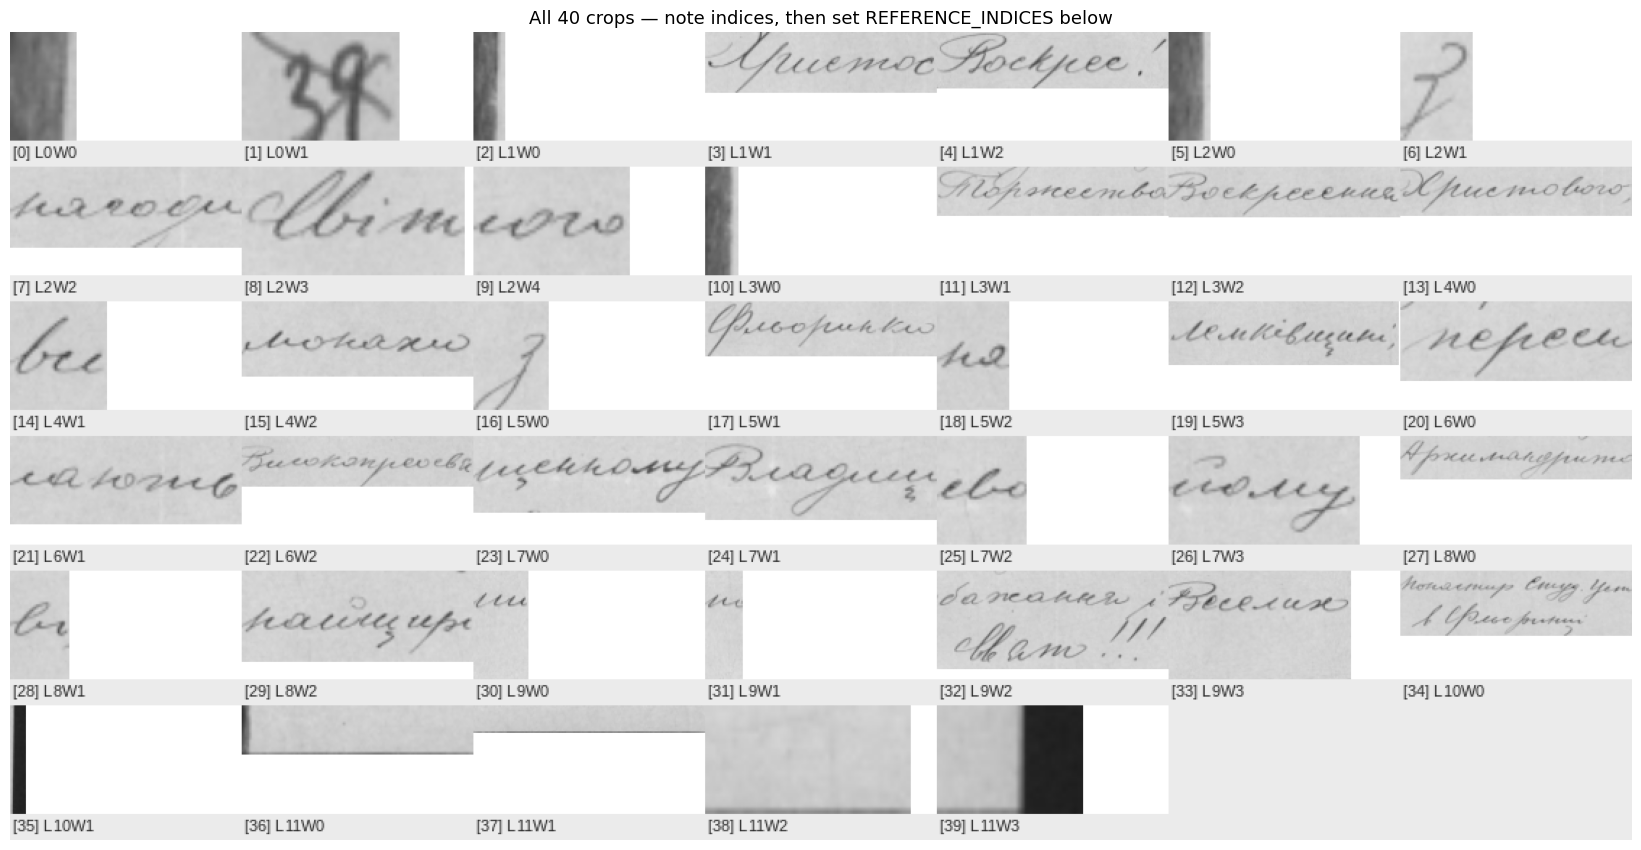

In [5]:
# Display all crops in a numbered grid
N    = len(all_crops)
COLS = 7
ROWS = (N + COLS - 1) // COLS
CW, CH = 160, 75

canvas = Image.new('RGB', (COLS * CW, ROWS * (CH + 18)), (235, 235, 235))
draw   = ImageDraw.Draw(canvas)
try:
    font = ImageFont.truetype(
        '/usr/share/fonts/truetype/liberation/LiberationSans-Regular.ttf', 11)
except Exception:
    font = ImageFont.load_default()

for idx, (li, wi, crop) in enumerate(all_crops):
    row, col = divmod(idx, COLS)
    ox, oy   = col * CW, row * (CH + 18)
    pil = Image.fromarray(crop).convert('RGB')
    sc  = min(CW / max(pil.width, 1), CH / max(pil.height, 1))
    pil = pil.resize((max(1, int(pil.width * sc)),
                      max(1, int(pil.height * sc))), Image.BILINEAR)
    bg  = Image.new('RGB', (CW, CH), (255, 255, 255))
    bg.paste(pil, (0, 0))
    canvas.paste(bg, (ox, oy))
    draw.text((ox + 2, oy + CH + 2), f'[{idx}] L{li}W{wi}',
              fill=(40, 40, 40), font=font)

fig = plt.figure(figsize=(22, ROWS * 1.35 + 0.5))
plt.imshow(canvas); plt.axis('off')
plt.title(f'All {N} crops — note indices, then set REFERENCE_INDICES below',
          fontsize=13)
plt.tight_layout(); plt.show()

Loaded 5 reference crops from /home/oles/DiffusionPen/generated/archival/crops
  [003]  152x40 px
  [004]  161x40 px
  [008]  64x31 px
  [019]  154x43 px
  [027]  234x45 px
Style tensor: torch.Size([5, 3, 64, 256])


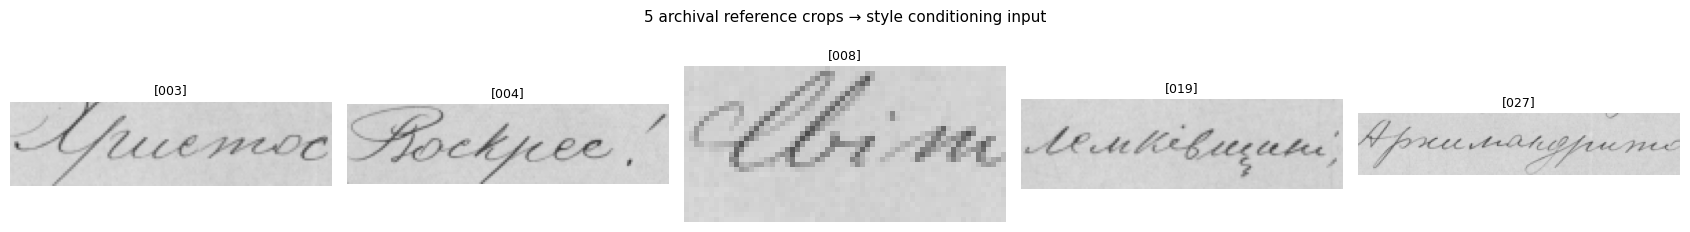

In [6]:
# Load reference crops directly from saved files — no segmentation cells needed
REFERENCE_INDICES = [3, 4, 8, 19, 27]
CROPS_DIR = os.path.join(OUTPUT_DIR, 'crops')

def load_crop_by_index(idx, crops_dir=CROPS_DIR):
    """Find and load the saved crop PNG by its numeric index."""
    prefix = f'word_{idx:03d}_'
    matches = [f for f in os.listdir(crops_dir) if f.startswith(prefix)]
    if not matches:
        raise FileNotFoundError(f'No crop file with index {idx:03d} in {crops_dir}')
    return np.array(Image.open(os.path.join(crops_dir, matches[0])).convert('L'))

ref_crops = [load_crop_by_index(i) for i in REFERENCE_INDICES]
print(f'Loaded {len(ref_crops)} reference crops from {CROPS_DIR}')
for i, (idx, crop) in enumerate(zip(REFERENCE_INDICES, ref_crops)):
    print(f'  [{idx:03d}]  {crop.shape[1]}x{crop.shape[0]} px')

def crops_to_tensor(crops_gray, h=IMG_HEIGHT, w=IMG_WIDTH):
    tensors = []
    for c in crops_gray:
        pil = Image.fromarray(c).convert('RGB')
        nw  = max(1, int(pil.width * h / pil.height))
        pil = pil.resize((nw, h), Image.BILINEAR)
        if pil.width < w:
            bg = Image.new('RGB', (w, h), (255, 255, 255))
            bg.paste(pil, (0, 0)); pil = bg
        elif pil.width > w:
            pil = pil.resize((w, h), Image.BILINEAR)
        tensors.append(TRANSFORM(pil))
    return torch.stack(tensors)

style_tensor = crops_to_tensor(ref_crops)   # [5, 3, 64, 256]
print(f'Style tensor: {style_tensor.shape}')

fig, axes = plt.subplots(1, 5, figsize=(17, 2.5))
for ax, crop, idx in zip(axes, ref_crops, REFERENCE_INDICES):
    ax.imshow(crop, cmap='gray', vmin=0, vmax=255)
    ax.set_title(f'[{idx:03d}]', fontsize=9)
    ax.axis('off')
plt.suptitle('5 archival reference crops → style conditioning input', fontsize=11)
plt.tight_layout(); plt.show()

## Load Diffusion Model

v9 checkpoint — Extended Balanced 124K, `num_res_blocks=2`.

In [7]:
from diffusers import AutoencoderKL, DDIMScheduler
from transformers import CanineTokenizer, CanineModel
from types import SimpleNamespace
from unet import UNetModel

def strip_dp(sd):
    out = {}
    for k, v in sd.items():
        k = k.replace('module.', '', 1)
        if k.startswith('text_encoder.module.'):
            k = k.replace('text_encoder.module.', 'text_encoder.', 1)
        out[k] = v
    return out

print('Loading checkpoint...')
sd = strip_dp(torch.load(CHECKPOINT, map_location='cpu'))
num_classes = sd['label_emb.weight'].shape[0]
print(f'  num_classes = {num_classes}')

tokenizer = CanineTokenizer.from_pretrained('google/canine-c')
canine    = CanineModel.from_pretrained('google/canine-c')

unet = UNetModel(
    image_size=(IMG_HEIGHT, IMG_WIDTH), in_channels=4, model_channels=320,
    out_channels=4, num_res_blocks=2, attention_resolutions=(1, 1),
    channel_mult=(1, 1), num_heads=4, num_classes=num_classes, context_dim=320,
    vocab_size=WORD_CHAR_CLASSES, text_encoder=canine,
    args=SimpleNamespace(interpolation=False, mix_rate=None),
)
unet.load_state_dict(sd)
unet = unet.to(DEVICE).eval()

print('Loading VAE...')
vae = AutoencoderKL.from_pretrained(SD_PATH, subfolder='vae').to(DEVICE)
vae.requires_grad_(False)
noise_scheduler = DDIMScheduler.from_pretrained(SD_PATH, subfolder='scheduler')

print('Model ready.')

Loading checkpoint...
  num_classes = 323


Loading weights: 100%|██████████| 246/246 [00:00<00:00, 878.80it/s, Materializing param=projection.conv.weight]                                        
CanineModel LOAD REPORT from: google/canine-c
Key                          | Status     |  | 
-----------------------------+------------+--+-
char_embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading VAE...
Model ready.


## Generate Ukrainian Text in Archival Style

`y=None` is passed to the UNet — the continuous style pathway handles everything.
The archival crops are the only style signal; no training writer index is used.

In [11]:
GEN_TEXT  = 'Христос Воскрес'
CFG_SCALE = 5.0

@torch.no_grad()
def generate_word(word, style_ref, cfg=CFG_SCALE):
    """Zero-shot generation conditioned on style_ref only.

    style_ref : [N, 3, H, W] tensor of reference images (N=5 recommended).
    y=None    : discrete label_emb branch is bypassed; continuous style pathway only.
    Returns grayscale PIL image.
    """
    tok = tokenizer([word], padding='max_length', truncation=True,
                    return_tensors='pt', max_length=40).to(DEVICE)
    null_tok = tokenizer([''], padding='max_length', truncation=True,
                         return_tensors='pt', max_length=40).to(DEVICE)
    sb = style_ref.unsqueeze(0).to(DEVICE)
    sf = style_extractor(
        sb.reshape(-1, 3, IMG_HEIGHT, IMG_WIDTH)).to(DEVICE)
    x  = torch.randn(1, 4, IMG_HEIGHT // 8, IMG_WIDTH // 8, device=DEVICE)
    noise_scheduler.set_timesteps(50)
    for t in noise_scheduler.timesteps:
        ts  = (torch.ones(1, device=DEVICE) * t.item()).long()
        np_ = unet(x, ts, tok,      None, original_images=sb,
                   mix_rate=None, style_extractor=sf)
        nu  = unet(x, ts, null_tok, None, original_images=sb,
                   mix_rate=None, style_extractor=sf)
        np_ = nu + cfg * (np_ - nu)
        x   = noise_scheduler.step(np_, t, x).prev_sample
    img = vae.decode(x / 0.18215).sample
    img = (img / 2 + 0.5).clamp(0, 1)
    return torchvision.transforms.ToPILImage()(img[0]).convert('L')


def crop_h(arr):
    _, th = cv2.threshold(arr, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    coords = cv2.findNonZero(th)
    if coords is None:
        return arr
    x, _, w, _ = cv2.boundingRect(coords)
    return arr[:, x:x + w]


def stitch(word_imgs, words, gap=16, canvas_h=104, gen_h=64):
    li  = max(range(len(words)), key=lambda i: len(words[i]))
    acw = Image.fromarray(word_imgs[li]).width / max(len(words[li]), 1)
    pad = canvas_h - gen_h
    parts = [np.ones((canvas_h, gap), dtype=np.uint8) * 255]
    for word, arr in zip(words, word_imgs):
        sw = max(int(acw * len(word)), int(acw * 2))
        r  = np.array(Image.fromarray(arr).resize((sw, gen_h)))
        parts += [np.pad(r, ((0, pad), (0, 0)), constant_values=255),
                  np.ones((canvas_h, gap), dtype=np.uint8) * 255]
    return Image.fromarray(np.concatenate(parts, axis=1))


print('Generation functions ready.')

Generation functions ready.


  generating: Христос
  generating: Воскрес


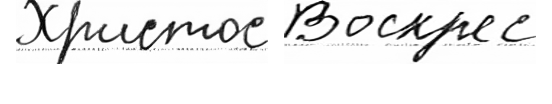

Saved.


In [12]:
words     = GEN_TEXT.strip().split()
word_imgs = []
for word in words:
    print(f'  generating: {word}')
    img = generate_word(word, style_tensor, cfg=CFG_SCALE)
    word_imgs.append(crop_h(np.array(img)))

sentence = stitch(word_imgs, words)
sentence.save(os.path.join(OUTPUT_DIR, 'generated_sentence.png'))
display(sentence)
print('Saved.')

## Comparison Figure

Final two-row panel suitable for the thesis:
- **Row 1:** 5 archival reference crops (style conditioning only)
- **Row 2:** Generated Ukrainian sentence in that historical style

Saved: /home/oles/DiffusionPen/generated/archival/comparison_archival.png


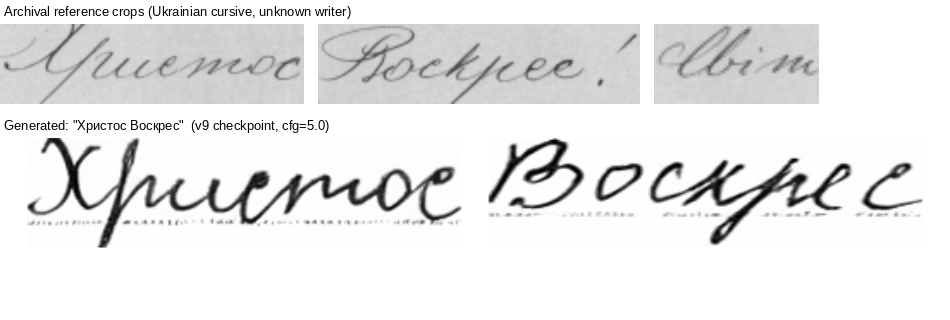

In [14]:
PANEL_W = 950
REF_H   = 80
LBL_H   = 20

# Build reference strip from the loaded ref_crops
ref_strip = Image.new('L', (PANEL_W, REF_H), 255)
x = 0
for crop in ref_crops:
    nw = max(1, int(crop.shape[1] * REF_H / max(crop.shape[0], 1)))
    pil = Image.fromarray(crop).resize((nw, REF_H), Image.BILINEAR)
    if x + pil.width > PANEL_W:
        break
    ref_strip.paste(pil, (x, 0))
    x += pil.width + 14

gen_w, gen_h = sentence.size
gen_resized  = sentence.resize(
    (PANEL_W, max(1, int(gen_h * PANEL_W / gen_w))), Image.BILINEAR)

try:
    font = ImageFont.truetype(
        '/usr/share/fonts/truetype/liberation/LiberationSans-Regular.ttf', 13)
except Exception:
    font = ImageFont.load_default()

total_h = LBL_H + REF_H + 14 + LBL_H + gen_resized.height + 8
panel   = Image.new('L', (PANEL_W, total_h), 255)
draw    = ImageDraw.Draw(panel)
y = 4
draw.text((4, y),
          'Archival reference crops (Ukrainian cursive, unknown writer)',
          fill=0, font=font)
y += LBL_H
panel.paste(ref_strip, (0, y))
y += REF_H + 14
draw.text((4, y),
          f'Generated: "{GEN_TEXT}"  (v9 checkpoint, cfg={CFG_SCALE})',
          fill=0, font=font)
y += LBL_H
panel.paste(gen_resized, (0, y))

out_path = os.path.join(OUTPUT_DIR, 'comparison_archival.png')
panel.save(out_path)
print(f'Saved: {out_path}')
display(panel)

## Discussion

### What this demonstrates

The model generates coherent Ukrainian text in a style conditioned on five word crops
from a century-old archival letter. This is a zero-shot generalisation along three
independent axes:

1. **Unseen writer** — the monastery writer is not in the 323 training identities
2. **Temporal domain gap** — ~100-year-old dip-pen cursive vs. modern ballpoint training data
3. **Script era gap** — pre-reform Ukrainian orthography (historical letterforms) used
   as style source; modern standard Ukrainian generated as output

If the generated output preserves characteristic properties of the archival style —
stroke width, pen pressure, letter slant, spacing rhythm — it is strong evidence that
the MobileNetV2 triplet encoder captures **geometry of stroke formation** rather than
Cyrillic-specific visual patterns.

### Comparison to IAM experiment

| Axis | IAM experiment | Archival experiment |
|------|---------------|--------------------|
| Script | Latin → Cyrillic | Old Cyrillic → Modern Cyrillic |
| Writer | Unseen (IAM) | Unseen (archival) |
| Era | Contemporary | ~100 years ago |
| Medium | Document scan | Photo of archival letter |

The archival experiment is a **stricter** test: the reference images differ from training
data in era, medium, and orthographic conventions simultaneously.

### Limitations

- Word segmentation from a photograph (rather than a clean scan) may produce imperfect
  crops; quality of style transfer depends on quality of reference crops.
- The aged-paper background may shift the style embedding slightly from the training
  distribution (training corpus has clean white background).
- Evaluation is qualitative. A quantitative study (human rater perceptual similarity
  between reference and generated) would strengthen the thesis claim.